In [112]:
Real_Noise_Dir = "./Real Noise Examples/"
Real_Noise_Save_Dir = "./Real Noise From Dis/"
Dis_Save_Dir = "./Dis Noise From Real Noise/"
file = "Aircraft.wav"
import torchaudio
Real_Noise = torchaudio.load(Real_Noise_Dir + file)

In [ ]:
from common.Reading_path_test import loading_paths_from_MAT
Pri_path, Secon_path = loading_paths_from_MAT(folder='Pz and Sz', subfolder='Dongyuan', Pri_path_file_name='Primary_path.mat', Sec_path_file_name='Secondary_path.mat')


In [114]:
# # from scipy.signal import 
# from scipy.fft import fft, ifft
# import numpy as np
# len_path = len(Pri_path)
# Real_Noise, fs = torchaudio.load(Real_Noise_Dir + file)
# Real_Noise = Real_Noise.squeeze()
# len_noise = len(Real_Noise)
# fft_len = len_path + len_noise - 1 
# P = fft(Pri_path, n=fft_len)
# S = fft(Secon_path, n=fft_len)
# Re = fft(Real_Noise.numpy(), n=fft_len)
# Dis = Re.squeeze() * P
# dis = ifft(Dis)
# import torch
# torchaudio.save(Dis_Save_Dir+file, torch.tensor(dis), fs)
# alpha = 0
# Re = Dis * P.conj() / (np.abs(P) ** 2 + alpha)
# re = ifft(Re)
# torchaudio.save(Real_Noise_Save_Dir+file, torch.tensor(re), fs)
# from scipy.signal import  welch
# f_Noise, Pxx_Noise = welch(Real_Noise, fs, scaling="spectrum")
# f_re, Pxx_re = welch(re, fs, scaling="spectrum")
# import matplotlib.pyplot as plt
# plt.semilogy(f_Noise, Pxx_Noise, color="blue")
# plt.semilogy(f_re[:len(Pxx_re)//2], Pxx_re[:len(Pxx_re)//2], color="green")

In [143]:
def make_ref(file_name):
    print(file_name)
    len_path = len(Pri_path)
    dis, fs = torchaudio.load(file_name)
    dis = dis.mean(dim=0, keepdim=True).squeeze()
    print(dis.shape)
    len_noise = len(dis)
    fft_len = len_path + len_noise - 1 
    P = fft(Pri_path, n=fft_len)
    S = fft(Secon_path, n=fft_len)
    Dis = fft(dis.numpy(), n=fft_len)
    alpha = 0.1
    Re = Dis * P.conj() / (np.abs(P) ** 2 + alpha)
    re = ifft(Re).real
    print(np.max(re))
    torchaudio.save(Real_Noise_Save_Dir+file_name, torch.tensor(re), fs)
    from scipy.signal import  welch
    f_re, Pxx_re = welch(re, fs, scaling="spectrum")
    import matplotlib.pyplot as plt
    plt.semilogy(f_re[:len(Pxx_re)//2], Pxx_re[:len(Pxx_re)//2], color="green")

In [217]:
import torch
import torchaudio
import numpy as np
from scipy.fft import fft, ifft
from scipy.signal import welch
import matplotlib.pyplot as plt

def make_ref(file_name, alpha=0):
    print(f"Processing: {file_name}")
    len_path = len(Pri_path)
    
    dis, fs = torchaudio.load(file_name)
    dis = dis.mean(dim=0).squeeze()
    print(f"Input shape: {dis.shape}")
    
    len_noise = len(dis)
    fft_len = len_path + len_noise - 1 
    
    P = fft(Pri_path, n=fft_len)
    Dis = fft(dis.numpy(), n=fft_len)
    
    Re = Dis * P.conj() / (np.abs(P) ** 2 + alpha)
    # Re = Re * ((np.abs(P) ** 2 + alpha) / (np.abs(P) ** 2 + 1e-12))
    re_long = ifft(Re).real
    re = re_long[:len_noise]
    re_max = np.max(np.abs(re))
    print(re_max)
    re = re / re_max
    re_tensor = torch.tensor(re, dtype=torch.float32).unsqueeze(0)
    save_path = Real_Noise_Save_Dir + file_name
    torchaudio.save(save_path, re_tensor, fs)
    print(f"Saved: {save_path}")

    # f_re, Pxx_re = welch(re, fs, scaling="spectrum")
    # plt.semilogy(f_re, Pxx_re, color="green", label="Recovered")
    # plt.legend()
    # plt.show()

In [219]:
import os
dir_path = "20250506_音データ/"
file_names = os.listdir(dir_path)
for i in file_names:
    make_ref(dir_path + i, 0.0001)
    

Processing: 20250506_音データ/B_Ⅰ_1_20251029.wav
Input shape: torch.Size([882001])
0.686143232589767
Saved: ./Real Noise From Dis/20250506_音データ/B_Ⅰ_1_20251029.wav
Processing: 20250506_音データ/B_Ⅲ_2_20251029.wav
Input shape: torch.Size([441001])
1.1847123524741088
Saved: ./Real Noise From Dis/20250506_音データ/B_Ⅲ_2_20251029.wav
Processing: 20250506_音データ/B_Ⅰ_3_20251029.wav
Input shape: torch.Size([882001])
0.7116690882133777
Saved: ./Real Noise From Dis/20250506_音データ/B_Ⅰ_3_20251029.wav
Processing: 20250506_音データ/A_Ⅱ_1_20250917.wav
Input shape: torch.Size([793801])
1.1344523282678405
Saved: ./Real Noise From Dis/20250506_音データ/A_Ⅱ_1_20250917.wav
Processing: 20250506_音データ/B_Ⅱ_1_20251029.wav
Input shape: torch.Size([793801])
1.1604048731915302
Saved: ./Real Noise From Dis/20250506_音データ/B_Ⅱ_1_20251029.wav
Processing: 20250506_音データ/B_Ⅳ_2_20251029.wav
Input shape: torch.Size([441001])
0.578092298681984
Saved: ./Real Noise From Dis/20250506_音データ/B_Ⅳ_2_20251029.wav
Processing: 20250506_音データ/A_Ⅲ_2_20250917.w

In [204]:
from Disturbance_generation import Disturbance_generation_from_real_noise
from loading_real_wave_noise_v2 import loading_real_wave_noise
import os
dir_path = "/20250506_音データ/"
file_names = os.listdir(dir_path)
for i in file_names:
    waveform, fs = loading_real_wave_noise(folde_name=dir_path, sound_name=i)
    Dis, Fx, Re = Disturbance_generation_from_real_noise(fs=fs, Repet=0, wave_form=waveform, Pri_path=Pri_path, Sec_path=Secon_path)
    torchaudio.save("Dis Noise From Real Noise/20250506_音データ/" + i, Dis, fs)

FileNotFoundError: [Errno 2] No such file or directory: '/20250506_音データ/'

Processing: ./20250506_音データ/A_Ⅰ_1_20250917.wav
Input shape: torch.Size([882001])
1000.5723518221579
Saved: ./Real Noise From Dis/./20250506_音データ/A_Ⅰ_1_20250917.wav


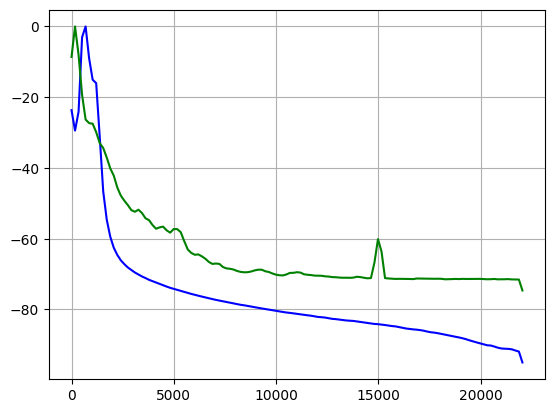

In [216]:
import os
dir_path = "./20250506_音データ/"
file_path = "A_Ⅰ_1_20250917.wav"

make_ref(dir_path + file_path, 0.0001)

from Disturbance_generation import Disturbance_generation_from_real_noise
from loading_real_wave_noise_v2 import loading_real_wave_noise

waveform, fs = loading_real_wave_noise(folde_name=Real_Noise_Save_Dir+"20250506_音データ/", sound_name=file_path)
Dis, Fx, Re = Disturbance_generation_from_real_noise(fs=fs, Repet=0, wave_form=waveform, Pri_path=Pri_path, Sec_path=Secon_path)
torchaudio.save("Dis Noise From Real Noise/20250506_音データ/" + file_path, Dis, fs)

from scipy import signal
import torchaudio
import numpy as np
import matplotlib.pyplot as plt

file = "Dis Noise From Real Noise/20250506_音データ/A_Ⅰ_1_20250917.wav"
wave, fs = torchaudio.load(file)
f, Pxx_den_dis = signal.welch(wave.squeeze().numpy(), fs, scaling="spectrum")
Pxx_dB_dis = 10 * np.log10(Pxx_den_dis / np.max(Pxx_den_dis))
file = "20250506_音データ/A_Ⅰ_1_20250917.wav"
wave, fs = torchaudio.load(file)
wave = wave.mean(dim=0)
f, Pxx_den_ori = signal.welch(wave.squeeze().numpy(), fs, scaling="spectrum")
max = np.max( Pxx_den_ori)
# Pxx_dB_dis = 10 * np.log10(Pxx_den_dis / max)
Pxx_dB_ori = 10 * np.log10(Pxx_den_ori / max)
plt.plot(f, Pxx_dB_dis, color="blue")
plt.plot(f, Pxx_dB_ori, color="green")
plt.grid()

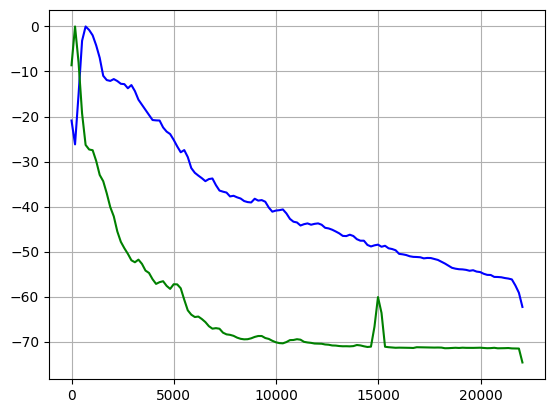

In [187]:
num = 1
file = "Dis Noise From Real Noise/20250506_音データ/A_Ⅰ_" + str(num) + "_20250917.wav"
wave, fs = torchaudio.load(file)
f, Pxx_den_dis = signal.welch(wave.squeeze().numpy(), fs, scaling="spectrum")
Pxx_dB_dis = 10 * np.log10(Pxx_den_dis / np.max(Pxx_den_dis))
file = "20250506_音データ/A_Ⅰ_" + str(num) + "_20250917.wav"
wave, fs = torchaudio.load(file)
wave = wave.mean(dim=0)
f, Pxx_den_ori = signal.welch(wave.squeeze().numpy(), fs, scaling="spectrum")
Pxx_dB_dis = 10 * np.log10(Pxx_den_dis / np.max(Pxx_den_dis))
Pxx_dB_ori = 10 * np.log10(Pxx_den_ori / np.max(Pxx_den_ori))
plt.plot(f, Pxx_dB_dis, color="blue")
plt.plot(f, Pxx_dB_ori, color="green")
plt.grid()